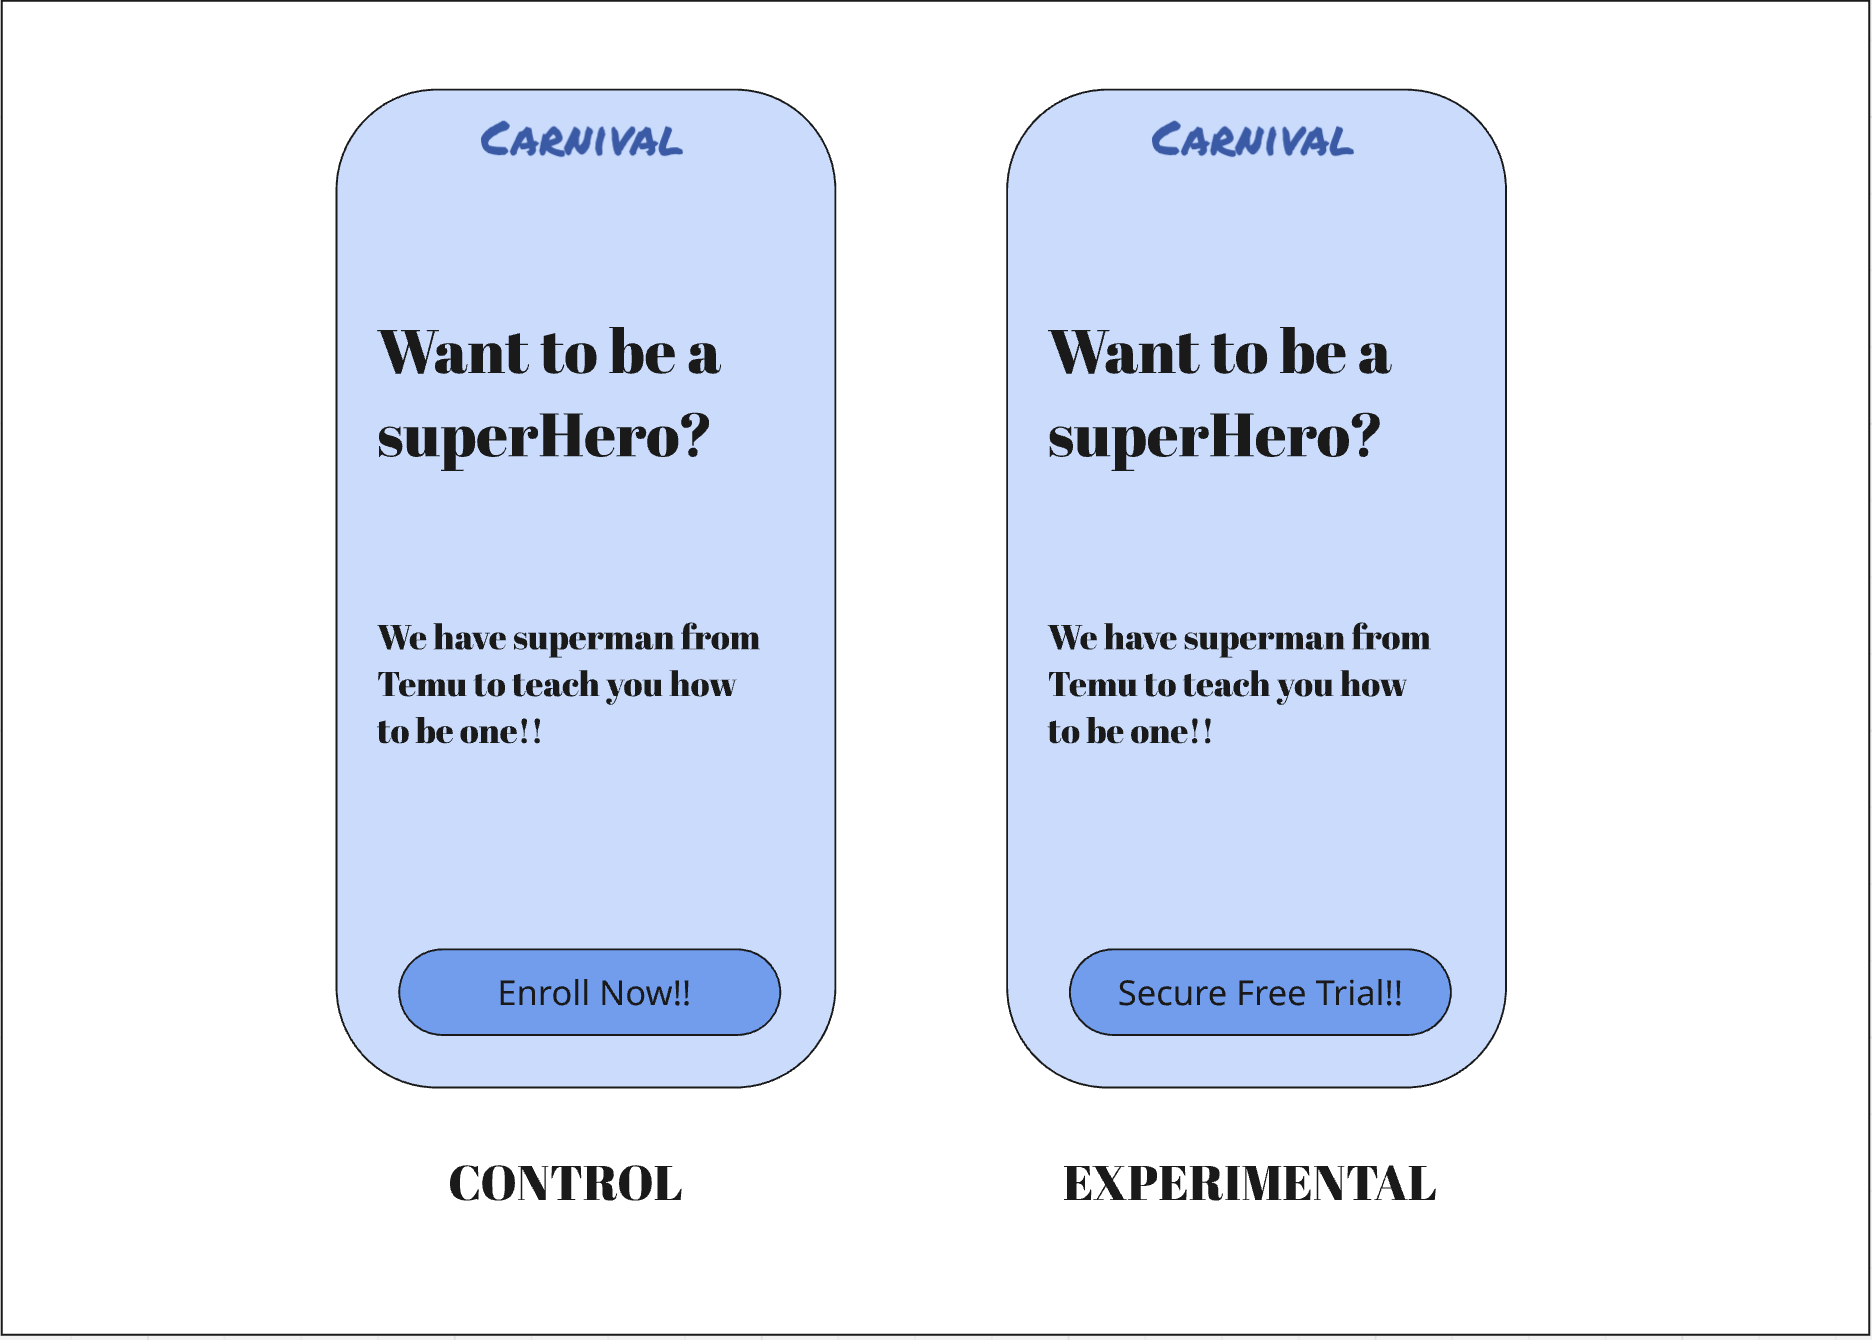

Defining hypothesis:

H0: p(con) = p(exp)

H1: p(con) ≠ p(exp)

In [43]:
import numpy as np
import pandas as pd
from scipy.stats import norm #visualize rejection region
import seaborn as sns
import matplotlib.pyplot as plt


In [44]:
#load the data from the CSV file
df_ab_test = pd.read_csv('ab_test_click_data (1).csv')

#Display the first few rows of the dataframe to confirm if its loaded correctly
print(df_ab_test.head())
print(df_ab_test.describe())
print(df_ab_test.groupby("group").sum("click"))

   user_id  click group            timestamp
0        1      1   exp  2024-01-01 00:00:00
1        2      0   exp  2024-01-01 00:01:00
2        3      1   exp  2024-01-01 00:02:00
3        4      0   exp  2024-01-01 00:03:00
4        5      1   exp  2024-01-01 00:04:00
            user_id         click
count  20000.000000  20000.000000
mean   10000.500000      0.405250
std     5773.647028      0.490953
min        1.000000      0.000000
25%     5000.750000      0.000000
50%    10000.500000      0.000000
75%    15000.250000      1.000000
max    20000.000000      1.000000
         user_id  click
group                  
con    150005000   1989
exp     50005000   6116


A simple bar chart showing the total clicks versus no-clicks in each group can provide a clear visual comparison of user engagement.

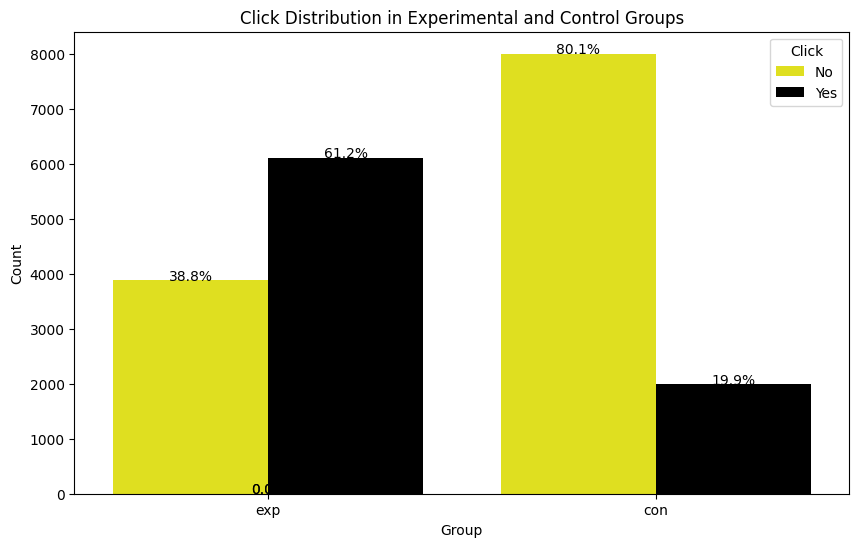

In [45]:
# Custom palette for yellow and black
palette = {0: 'yellow', 1: 'black'} # assuming 0 is for no-click and 1 for click

# Plotting the click distribution for each with the custom colors
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_ab_test, x='group', hue='click', palette=palette) # Assign the axes to ax
plt.title('Click Distribution in Experimental and Control Groups')
plt.xlabel('Group')
plt.ylabel('Count')
plt.legend(title='Click', loc='upper right', labels=['No', 'Yes'])

#Calculate the percentages and annotate the bars
group_counts = df_ab_test.groupby(['group']).size()
group_click_counts = df_ab_test.groupby(['group', 'click']).size().reset_index(name='count')

for p in ax.patches:
  height = p.get_height()
  # find the group and click type for the current bar
  group = 'exp' if p.get_x() == 0 else 'con'
  click = 1 if p.get_y() == 1 else 0
  total = group_counts[group]
  percentage = 100 * height / total
  ax.text(p.get_x() + p.get_width() / 2., height + 5, f'{percentage:.1f}%', ha="center", color='black', fontsize=10)

plt.show()

Parameters of the model from power analysis:

Beta: Probability of type 2 error

(1-Beta): power of the test

alpha: Probability of type 1 error, Significance level

Delta: Minimum Detactable Effect




In [46]:
alpha = 0.05
print("Alpha: significance level is:", alpha)

delta = 0.1
print("Delta: minimum detectable effect is:", delta)

Alpha: significance level is: 0.05
Delta: minimum detectable effect is: 0.1


Calculating total number of clicks per group by summing clicks

In [47]:
N_con = df_ab_test[df_ab_test["group"] == "con"].count()
N_exp = df_ab_test[df_ab_test["group"] == "exp"].count()

# calculating the total number of clicks per group by summing 1s
X_con = df_ab_test.groupby("group")["click"].sum().loc["con"]
X_exp = df_ab_test.groupby("group")["click"].sum().loc["exp"]

#printing for visibility
print(df_ab_test.groupby("group")["click"].sum())
print("Number of user in controlL ", N_con)
print("Number of user in experiment: ", N_exp)
print("number of clicks in Control: ", X_con)
print("number of clicks in Experiment: ", X_exp)

group
con    1989
exp    6116
Name: click, dtype: int64
Number of user in controlL  user_id      10000
click        10000
group        10000
timestamp        0
dtype: int64
Number of user in experiment:  user_id      10000
click        10000
group        10000
timestamp    10000
dtype: int64
number of clicks in Control:  1989
number of clicks in Experiment:  6116


Calculating Pooled estimates for clicks per group


In [48]:
p_con_hat = X_con/N_con
p_exp_hat = X_exp/N_exp
print("Click Probability in Control Group:", p_con_hat)
print("Click Probability in Experiment Group:", p_exp_hat)

#computing the estimate of pooled clicked probability
p_pooled_hat = (X_con + X_exp)/(N_con + N_exp)
print("Pooled Click Probability:", p_pooled_hat)

Click Probability in Control Group: user_id      0.1989
click        0.1989
group        0.1989
timestamp       inf
dtype: float64
Click Probability in Experiment Group: user_id      0.6116
click        0.6116
group        0.6116
timestamp    0.6116
dtype: float64
Pooled Click Probability: user_id      0.40525
click        0.40525
group        0.40525
timestamp    0.81050
dtype: float64


Calculating Pooled Variance

In [49]:
# computing the estimate of pooled variance
pooled_variance = p_pooled_hat * (1-p_pooled_hat) * (1/N_con + 1/N_exp)
print("P^_pooled is: ", p_pooled_hat)
print("pooled_variance is: ", pooled_variance)

P^_pooled is:  user_id      0.40525
click        0.40525
group        0.40525
timestamp    0.81050
dtype: float64
pooled_variance is:  user_id      0.000048
click        0.000048
group        0.000048
timestamp         inf
dtype: float64


Calculating the Standard Error and Test statistics

In [50]:
# computing the standard error of the test
SE = np.sqrt(pooled_variance)
print("Standard error os: ", SE)

# computing the test statisitcs of Z-test
Test_stat = (p_con_hat - p_exp_hat)/SE
print("Test statistics is: ", Test_stat)

# critical value of the z_test
Z_crit = norm.ppf(1-alpha/2)
print("Critical value of Z-test is: ", Z_crit)

Standard error os:  user_id      0.006943
click        0.006943
group        0.006943
timestamp         inf
dtype: float64
Test statistics is:  user_id     -59.441633
click       -59.441633
group       -59.441633
timestamp          NaN
dtype: float64
Critical value of Z-test is:  1.959963984540054


Calculating p_values of the Z-test

* A low p-value(p <=0.05) indicates strong evidence against the null hypothesis, so we reject the null hypothesis

* A high p-value(p > 0.05) indicates weak evidence against the null hypothesis, so we fail to reject the null hypthesis

In [51]:
# calculating the p_value
p_value = 2 * norm.sf(abs(Test_stat))

# Convert p_value to a float before rounding
# Assuming you want the first element of the array
p_value = float(p_value[0])

# function checking the statistical significance
def is_statistical_significance(p_value, alpha):
    """

    We assess whether there is statistical significance based on the p-value and alpha.

    Arguements:
    - p_value(float): The p-value resulting from a statistical test.
    - alpha(float, optional): The significance level threshold used to determine statistical significance. Defaults to 0.05.

    Returns:
    - Prints the assessment of statistical significance.

    """

    # print the rounded p-value to 3 decimal places
    print(f"p-value of the 2-sample Z-test: {round(p_value, 3)}")

    # Determine Statisitcal significance
    if p_value <= alpha:
      print("There is statistical significance.")
    else:
      print("There is no statistical significance.")

is_statistical_significance(p_value, alpha)

p-value of the 2-sample Z-test: 0.0
There is statistical significance.


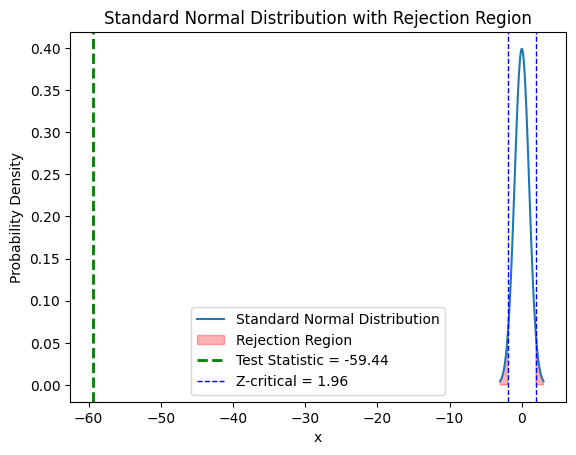

In [54]:
# parameters for the standard normal distribution
mu = 0  # mean
sigma = 1  # standard deviation
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
y = norm.pdf(x, mu, sigma)

import pandas as pd
Test_stat = pd.Series([-59.441633])
Z_crit = pd.Series([1.959963984540054])

# Get scalar values
test_stat_val = Test_stat.iloc[0] if hasattr(Test_stat, 'iloc') else Test_stat
z_crit_val = Z_crit.iloc[0] if hasattr(Z_crit, 'iloc') else Z_crit

# plot the standard normal distribution
plt.plot(x, y, label='Standard Normal Distribution')

# Shade the rejection region for a two-tailed test
plt.fill_between(x, y, where=(x < -z_crit_val) | (x > z_crit_val), color='red', alpha=0.3, label='Rejection Region')

# Adding Test Statistic
plt.axvline(test_stat_val, color='green', linestyle='dashed', linewidth=2, label=f'Test Statistic = {test_stat_val:.2f}')

# Adding z-critical values
plt.axvline(z_crit_val, color='blue', linestyle='dashed', linewidth=1, label=f'Z-critical = {z_crit_val:.2f}')
plt.axvline(-z_crit_val, color='blue', linestyle='dashed', linewidth=1)

# Adding labels and title
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Standard Normal Distribution with Rejection Region')
plt.legend()
plt.show()

Calculating the Confidence Interval of the test

In [104]:
#Calculate the Confidence Interval(CI) for a 2-sample Z-test
#  calculate the lower and upper bounfs of the Confidence interval

CI = [
    round((p_exp_hat - p_con_hat) - SE*Z_crit, 3), # lower bound of the CI, rounded up to 3 decimals
    round((p_exp_hat - p_con_hat) + SE*Z_crit, 3)  # upper bound of the CI, rounded up to 3 decimals
]

print("Confidence Interval of the 2 sample Z-test is: ", CI)


Confidence Interval of the 2 sample Z-test is:  [0           NaN
click       NaN
group       NaN
timestamp   NaN
user_id     NaN
dtype: float64, 0           NaN
click       NaN
group       NaN
timestamp   NaN
user_id     NaN
dtype: float64]


In [107]:
# Ensure scalar values are extracted if Series
p_exp_hat_val = p_exp_hat.iloc[0] if hasattr(p_exp_hat, 'iloc') else p_exp_hat
p_con_hat_val = p_con_hat.iloc[0] if hasattr(p_con_hat, 'iloc') else p_con_hat
SE_val = SE.iloc[0] if hasattr(SE, 'iloc') else SE
Z_crit_val = Z_crit.iloc[0] if hasattr(Z_crit, 'iloc') else Z_crit

# Calculate CI with float conversion
CI = [
    float(round((p_exp_hat_val - p_con_hat_val) - SE_val * Z_crit_val, 3)),
    float(round((p_exp_hat_val - p_con_hat_val) + SE_val * Z_crit_val, 3))
]

print("Confidence Interval of the 2-sample Z-test is:", CI)


Confidence Interval of the 2-sample Z-test is: [0.399, 0.426]


Testing for practical significance in A/B testing

In [113]:

def is_Practically_significant(delta, CI_95):
    """
    We assess here if the difference between Control and Experimental group is practically significant using the Minimum Detectable Effect (MDE) parameter from the Power Analysis.

    Arguments:
    - delta (float): The Minimum Detectable Effect (MDE) considered for practical significance.
    - CI_95 (tuple): A tuple representing the lower and upper bounds of the 95% Confidence Interval.

    Returns:
    - Prints whether the experiment has practical significance based on the MDE and CI.
    """

    # Extract lower bound of 95% Confidence Interval
    lower_bound_CI = CI_95[0]

    # Check if the lower bound of the CI is greater than or equal to delta
    if delta >= lower_bound_CI:
        print(f"We have practical significance! With MDE of {delta},\n The difference between Control and Experimental group is practically significant.")
        return True
    else:
        print(f"We don't have practical significance! With MDE of {delta}, \nThe difference between Control and Experimental group is not practically significant.")
        return False



# Call the function
significance = is_Practically_significant(delta, CI)
print("Lower bound of 95% confidence interval is: ", CI[0])

We don't have practical significance! With MDE of 0.1, 
The difference between Control and Experimental group is not practically significant.
Lower bound of 95% confidence interval is:  0.399
